In [1]:
import sys
sys.path.append("../")

import numpy as np 

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

from scipy.signal import convolve, gaussian
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture

from vi_rnn.saving import load_model
from vi_rnn.utils import *
from vi_rnn.load_data import * 

import pickle 
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

## Define util functions

In [2]:
def gmm_fit(neurons_fs, n_components, algo='bayes', n_init=50, random_state=None, mean_precision_prior=None,
            weight_concentration_prior_type='dirichlet_process', weight_concentration_prior=None):
    """
    fit a mixture of gaussians to a set of vectors
    :param neurons_fs: list of numpy arrays of shape n or numpy array of shape n x d
    :param n_components: int
    :param algo: 'em' or 'bayes'
    :param n_init: number of random seeds for the inference algorithm
    :param random_state: random seed for the rng to eliminate randomness
    :return: vector of population labels (of shape n), best fitted model
    """
    if isinstance(neurons_fs, list):
        X = np.vstack(neurons_fs).transpose()
    else:
        X = neurons_fs
    if algo == "em":
        model = GaussianMixture(n_components=n_components, n_init=n_init, random_state=random_state)
    else:
        model = BayesianGaussianMixture(n_components=n_components, covariance_type="full", n_init=n_init, random_state=random_state,
                                        init_params='random', mean_precision_prior=mean_precision_prior,
                                        weight_concentration_prior_type=weight_concentration_prior_type,
                                        weight_concentration_prior=weight_concentration_prior)
    model.fit(X)
    z = model.predict(X)
    return z, model

In [3]:
def cluster_loadings(m, n, A=None, W_inp=None, mechanism=None, algo='em', n_components=2, filename=None):
    R, N = m.shape[1], m.shape[0]
    
    N_s = 0
    if A is not None and mechanism != 'rank':
        N_s = A.shape[1]
        
    n_patterns = 2 * R + N_s 
    if W_inp is not None: n_patterns += 1 
    
    # Define data dictionary 
    x_labels = []
    
    pattern_loadings = np.zeros((N, n_patterns)) #r"$n_i^{(1)}$", r"$m_i^{(1)}$", r"$n_i^{(2)}$", r"$m_i^{(2)}$", r"$w_i$"
    for i in range(N):
        loadings = []
        for j in range(R):
            loadings.append(m[i, j])
            if i == 0:
                x_labels.append(rf'$m_{{{j+1}}}$')
        for j in range(R):
            loadings.append(n[j, i])
            if i == 0:
                x_labels.append(rf'$n_{{{j+1}}}$') 
             
        for j in range(N_s):
            loadings.append(A[i, j])
            if i == 0:
                x_labels.append(rf'$\alpha_{{{j+1}}}$') 

        if W_inp is not None : 
            loadings.append(W_inp[i, 2])
            x_labels.append(rf'$\I_{{stim}}') 
            
        pattern_loadings[i] = loadings
            
    fig, ax = plt.subplots(n_patterns, n_patterns, figsize=(8, 8))
    # Fit GMM to pattern loadings 
    colors = np.array(['teal', 'purple', 'orange'])
    colors = np.array(['#8fa06aac', '#c34b3596'])
    labels, model = gmm_fit(pattern_loadings, n_components=n_components, algo=algo, weight_concentration_prior=1e50, random_state=2020)
    probs = model.predict_proba(pattern_loadings)
    if algo == 'em':
        bic = model.aic(pattern_loadings)
    for i in range(n_patterns):
        for j in range(n_patterns):
            # only scatter lower triangle 
            if i > j: 
                ax[i, j].scatter(pattern_loadings[:, i], pattern_loadings[:, j], c=colors[labels])
            else: 
                ax[i, j].set_visible(False)
            if i == n_patterns - 1:
                ax[i, j].set_xlabel(x_labels[j], fontsize=14)
            if j == 0:
                ax[i, j].set_ylabel(x_labels[i], fontsize=14)
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            ax[i, j].tick_params(axis="y", labelsize=18)

    plt.tight_layout()
    
    if filename is not None:
        fig.savefig('loading_clusters.svg', format='svg')
    return model, probs, labels, pattern_loadings

### Load model for analysis

In [4]:
neuromodulation = "postsynaptic"
model_configs = [
    {
        "name": neuromodulation,
        "neuromodulation": neuromodulation, 
        "stim": True, 
        "rank": 1,
        "dales_law": False,  
        "activation": "clipped_relu",
        "bin_size": 0.05
    }]

In [55]:
rank = 1


model_nk340, _, _, _ = load_model(f'../models/dtt/nk340_mPFC_{neuromodulation}_rank_{rank}_seed_9_stim')

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
138 138
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
138


/network/iss/karalis/users/kaleab.belay/mnm/generate_figures/../vi_rnn/saving.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.BytesIO(b)

In [56]:
def get_orthogonalized_loadings(model):
    # Extract parameters 
    a, V, U, B, I = get_loadings(model)
    # Orthogonalize
    R, N = V.shape 
    U, S, V = np.linalg.svd(U @ V)
    U = U[:, :R]
    V = (V[:R].T*S[:R]).T
    A = model.rnn.transition.A.detach().numpy()
    hz = model.rnn.transition.hz.detach().numpy()
    h = model.rnn.transition.h.detach().numpy()

    return a, V, U, B, I, A, hz, h

In [57]:
a, V, U, B, I, A, hz, h = get_orthogonalized_loadings(model_nk340)


### Find the fixed points of the network

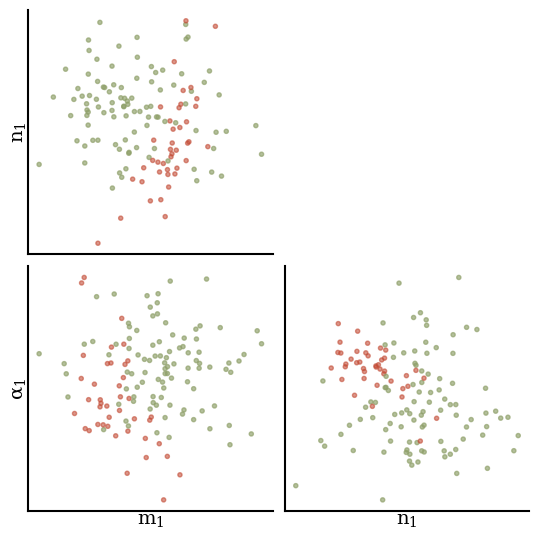

In [58]:
n_clusters=2
gmm, probs, labels, pattern_loadings = cluster_loadings(U, V, A, None, neuromodulation, algo='bayes', n_components=n_clusters)

In [59]:
model, _, _, _ = load_model(f'../models/dtt/nk340_mPFC_{neuromodulation}_rank_{rank}_seed_9_stim')

# Extract parameters 
a, V, U, B, I = get_loadings(model)                         
print(a)
A = model.rnn.transition.A.detach().numpy()
hz = model.rnn.transition.hz.detach().numpy()
h = model.rnn.transition.h.detach().numpy()
W_inp = model.rnn.transition.Wu.detach().numpy()
R, N = V.shape

# Orthogonalize
U, S, V = np.linalg.svd(U @ V)
U = U[:, :R]
V = (V[:R].T*S[:R]).T

# use orthogonalized low-rank matrices 
model.rnn.transition.m = torch.nn.Parameter(torch.from_numpy(U))
model.rnn.transition.n = torch.nn.Parameter(torch.from_numpy(V))

V_new, U_new, h_new = convert_clipped(V.T,U,h)
# test_conversion(V, V_new, U, U_new, h, h_new, N, R, s)

# s_vals, fixed_points = fixed_point_sweep(V_new, U_new, hz, h_new, a, A, W_inp, neuromodulation='postsynaptic', start=0.00, end=1.0, num_points=100)


dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
138 138
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
138
0.9115362


/network/iss/karalis/users/kaleab.belay/mnm/generate_figures/../vi_rnn/saving.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.BytesIO(b)

In [60]:
config = {
    'data_dir': '../data/recordings/nk340_mPFC/', 
    'dales_law': True,
    'out_dir': "../models/dtt/",
    'sampling_rate': 30_000,
    'bin_size': 0.05,
    'fr_threshold': 0.5,
    'threshold_neurons': True,
    'z_score_neuromod': False,
    'deconvolve': False,
    'convolve_spikes': True,
    'normalize_neuromod': True,
    'z_score_neurons': False,
    'center_neuromod': False,
    'load_physiology': False,
    'shuffle': False
}

In [11]:
config

{'data_dir': '../data/recordings/nk340_mPFC/',
 'dales_law': True,
 'out_dir': '../models/dtt/',
 'sampling_rate': 30000,
 'bin_size': 0.05,
 'fr_threshold': 0.5,
 'threshold_neurons': True,
 'z_score_neuromod': False,
 'deconvolve': False,
 'convolve_spikes': True,
 'normalize_neuromod': True,
 'z_score_neurons': False,
 'center_neuromod': False,
 'load_physiology': False,
 'shuffle': False}

In [36]:
spikes, spike_counts, neuromod_activity, trials_df, cell_types = load_data(config)
# split dataset into train and test samples based on amount of data available 
data_dur = spike_counts.shape[1] * config['bin_size']
# first find when the last trial is. Last trials is always odor, which lasts 120 seconds 
last_trial_timestamp = trials_df['cs'].max() + 120
baseline_dur = data_dur - last_trial_timestamp
# split into 75% train and 25% test samples. The tail end of the data will be used for training
config['baseline_test_start'] = int(data_dur - baseline_dur)
config['baseline_test_end'] = int(data_dur - 0.75 * baseline_dur) 

config['baseline_train_start'] = config['baseline_test_end'] 
config['baseline_train_end'] = int(data_dur) 

# prepare dataset 
x_test, s_test, stim_arr_test, seq_periods, _, _, _ = prepare_dataset(spike_counts, 
                                                                              neuromod_activity,
                                                                              trials_df, 
                                                                              config,
                                                                              test=True)
# load training s samples for normalization 
x_train, s_train, _, _, _, _, _ = prepare_dataset(spike_counts, 
                                            neuromod_activity,
                                            trials_df, 
                                            config,
                                            test=False)
s_min, s_max = s_train.min(), s_train.max() 
# s_test = (s_test - s_train.min()) / (s_train.max() - s_train.min())

# convert to torch tensors 
# x_test = torch.from_numpy(x_test).to(torch.float32) 
# s_test = torch.from_numpy(s_test).to(torch.float32)
# stim_arr_test = torch.from_numpy(stim_arr_test).to(torch.float32) 

t_end = 5183
174 neurons removed
cell type: [ 1  1  1 -1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1 -1  1
  1  1 -1  1 -1 -1  1 -1 -1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1
  1  1  1  1  1  1 -1  1 -1  1  1  1  1 -1 -1  1  1  1  1  1  1 -1 -1  1
  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1
  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1
  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1]
length of downsampled signal: 104055
length of original signal: 5202740
False
False
(4440,) (18630,)
Shape of data samples: (138, 18630), (18630,)
(13340,) (31830,)
Shape of data samples: (138, 31830), (31830,)


In [14]:
z0 = torch.tensor([0.0])
T=10000
s_train = (s_train - s_train.min()) / (s_train.max() - s_train.min())
Z_gen, _ = model.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=torch.from_numpy(s_train).view(1, 1, -1).to(torch.float32), noise_scale=0.0, sim_v=True, sim_s=False)

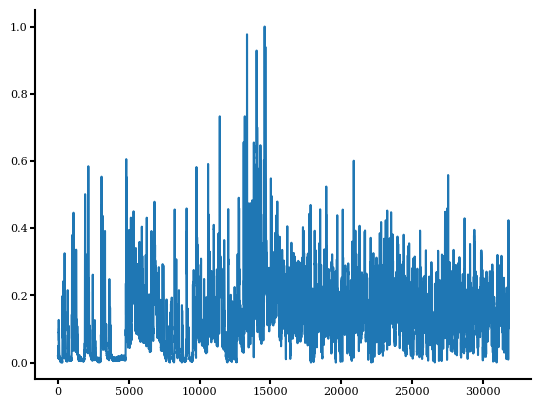

In [15]:
plt.plot(s_train)

In [61]:
# identify current model's neurons 
pop1_labels = np.where(labels == 0)[0]
pop2_labels = np.where(labels == 1)[0]

In [62]:
len(pop1_labels), len(pop2_labels)

(97, 41)

In [63]:
gmm.covariances_[0]

array([[ 0.00586025, -0.00311162, -0.00027798],
       [-0.00311162,  0.09733078, -0.00141896],
       [-0.00027798, -0.00141896,  0.03763513]])

In [64]:
gmm.covariances_[1]

array([[ 0.00817223,  0.00790768, -0.00375103],
       [ 0.00790768,  0.02638507, -0.01064567],
       [-0.00375103, -0.01064567,  0.01515999]])

In [65]:
len(pop1_labels) / U.shape[0], len(pop2_labels) / U.shape[0]

(0.7028985507246377, 0.2971014492753623)

In [66]:
T = 500
s_vals_ = [0.0,  0.2,  0.4,  0.6, 0.8, 1.0, ]
z_gens = []
# labels = []
u = torch.zeros((9, T))
u[2, 200:300] = 0.25
for s in s_vals_:
    z0 = torch.tensor([0.0]) 
    s_fxd = torch.tensor([s]).repeat(T)
    Z_gen, _ = model.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=u.unsqueeze(0), s=s_fxd.view(1, 1, -1).to(torch.float32), noise_scale=0.0, sim_v=True, sim_s=False)
    z_gens.append(Z_gen.flatten())
    # labels.append(s)


Text(0.5, 0, 'time')

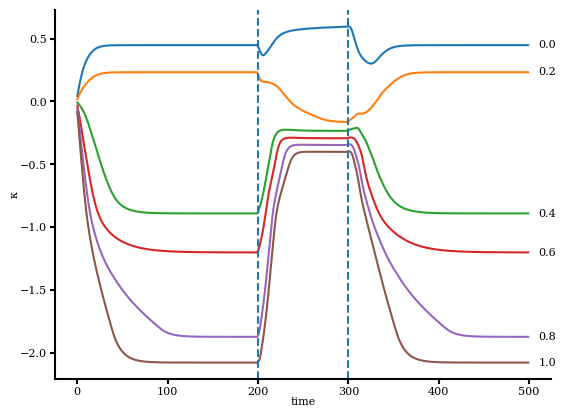

In [67]:
for i, z_gen in enumerate(z_gens):
    plt.plot(z_gen, label=labels[i])
    plt.text(510, z_gen[-1], f'{s_vals_[i]}', va='center')
plt.axvline(x=200, linestyle='--')
plt.axvline(x=300, linestyle='--')
plt.ylabel(rf'$\kappa$')
plt.xlabel('time')

In [68]:
def clipped_relu_gain(x, B):
    # x = np.asarray(x, float)
    if type(x) == np.ndarray:
        return ((x > -B) & (x < 0)).astype(float)
    return ((x > -B) & (x < 0)).to(torch.float32)

In [96]:
T=300
warmup = 100
pop1_rates, pop2_rates = [], []
pop1_gains, pop2_gains = [], []
pop_gains = []
z_vals = []
s_vals = [0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 1.0]
# s_vals = np.linspace(-1, 2, 10)
for s_ in s_vals:
    u = torch.zeros((9, T))
    s_val = s_

    with torch.no_grad():
        z0 = torch.tensor([0.0]) 
        s_fxd = torch.tensor([s_val]).repeat(T)
        Z_gen, _ = model.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=u.unsqueeze(0), s=s_fxd.view(1, 1, -1).to(torch.float32), noise_scale=0.0, sim_v=True, sim_s=False)
        z_vals.append(Z_gen.flatten()[-1].item())
        trajs = model.rnn.get_observation(Z_gen).squeeze(0).squeeze(-1)
        neuron_gains = clipped_relu_gain(trajs, torch.from_numpy(B).unsqueeze(1))
        # pop1_rates.append((trajs[pop1_labels, -1].mean(), trajs[pop1_labels, -1].std()))
        # pop2_rates.append((trajs[pop2_labels, -1].mean(), trajs[pop2_labels, -1].std()))
        phi_prime = neuron_gains.mean(axis=1)
        # rec_gains = (1 + s_val * model.rnn.transition.A.flatten()) * model.rnn.transition.n.flatten() * model.rnn.transition.m.flatten() * phi_prime
        # rec_gains = neuron_gains
        pop1_gains.append((neuron_gains[pop1_labels, warmup:].mean().item(), neuron_gains[pop1_labels, warmup:].std().item() / np.sqrt(len(pop1_labels)))) 
        pop2_gains.append((neuron_gains[pop2_labels, warmup:].mean().item(), neuron_gains[pop2_labels, warmup:].std().item() / np.sqrt(len(pop2_labels))))

        pop1_rates.append((trajs[pop1_labels, warmup:].mean().item(), trajs[pop1_labels, warmup:].std().item() / np.sqrt(len(pop1_labels)))) 
        pop2_rates.append((trajs[pop2_labels, warmup:].mean().item(), trajs[pop2_labels, warmup:].std().item() / np.sqrt(len(pop2_labels))))

In [97]:
pop1_rates = np.array(pop1_rates)
pop2_rates = np.array(pop2_rates)

pop1_gains = np.array(pop1_gains)
pop2_gains = np.array(pop2_gains)

/tmp/ipykernel_301413/3916205087.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Firing rates')

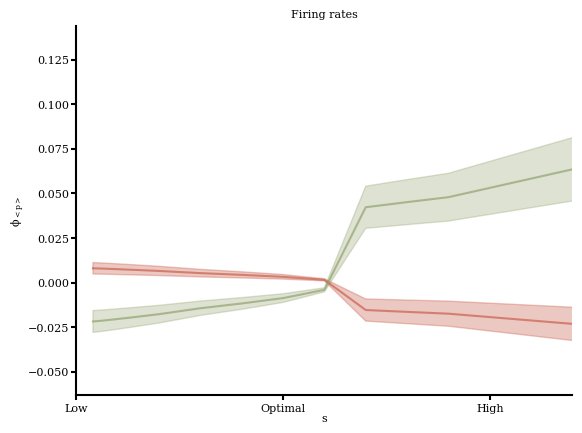

In [98]:
c1, c2 = '#c34b3596', '#8fa06aac' 
plt.plot(s_vals, pop1_rates[:, 0], color=c1)
plt.fill_between(s_vals, pop1_rates[:, 0] - pop1_rates[:, 1], pop1_rates[:, 0] + pop1_rates[:, 1], alpha=0.3, color=c1)
plt.plot(s_vals[:], pop2_rates[:, 0], color=c2)
plt.fill_between(s_vals, pop2_rates[:, 0] - pop2_rates[:, 1], pop2_rates[:, 0] + pop2_rates[:, 1], alpha=0.3, color=c2)
plt.ylabel(r"$\phi_{<p>}$")
plt.xlabel('s')
plt.xticks([0, 0.25, 0.5], labels=['Low', 'Optimal', 'High'])
plt.xlim([0, 0.6])
plt.legend()
plt.title('Firing rates')
# plt.savefig('pop_rates_model.svg', format='svg')

/tmp/ipykernel_301413/492909154.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Gains')

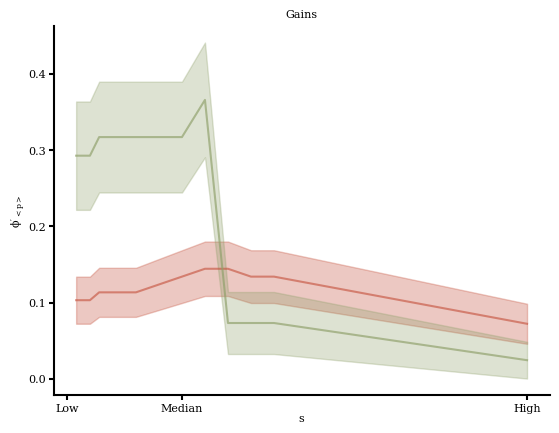

In [99]:
plt.plot(s_vals, pop1_gains[:, 0], color=c1)
plt.fill_between(s_vals, pop1_gains[:, 0] - pop1_gains[:, 1], pop1_gains[:, 0] + pop1_gains[:, 1], alpha=0.3, color=c1)
plt.plot(s_vals, pop2_gains[:, 0], color=c2)
plt.fill_between(s_vals, pop2_gains[:, 0] - pop2_gains[:, 1], pop2_gains[:, 0] + pop2_gains[:, 1], alpha=0.3, color=c2)
plt.ylabel(r"$\phi'_{<p>}$")
plt.xlabel('s')
plt.xticks([0, 0.25, 1.0], labels=['Low', 'Median', 'High'])
plt.legend()
plt.title('Gains')
# plt.savefig('pop_gains.svg', format='svg')

In [87]:
x_combined = np.hstack([x_train, x_test])
s_combined = np.hstack([s_train, s_test]) 

x_combined /= x_combined.std(axis=1, keepdims=True)
s_combined = (s_combined - s_train.min()) / (s_train.max() - s_train.min())
# s_combined = (s_combined - s_combined.mean()) / s_combined.std()
pop1_rates = x_combined[pop1_labels].mean(axis=0)
pop2_rates = x_combined[pop2_labels].mean(axis=0)

In [91]:
binned_firing_rates = []
bins = np.linspace(0, 0.8, 10)
for i in range(x_combined.shape[0]):
    df = pd.DataFrame({'s': s_combined, 'neuron_rate': x_combined[i]})
    df['s_bin'] = pd.cut(df['s'], bins=bins)
    grouped = df.groupby('s_bin').agg(
        s_center=('s', 'min'),
        neuron_rate=('neuron_rate', 'mean'),
    ).dropna() 
    binned_firing_rates.append(grouped['neuron_rate'])

/tmp/ipykernel_301413/937773528.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('s_bin').agg(
/tmp/ipykernel_301413/937773528.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('s_bin').agg(
/tmp/ipykernel_301413/937773528.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('s_bin').agg(
/tmp/ipykernel_301413/937773528.py:6: FutureWarning: The default of

In [92]:
binned_firing_rates = np.array(binned_firing_rates) 
pop1_firing_rates = binned_firing_rates[pop1_labels].mean(axis=0)
pop1_firing_rate_stdevs = binned_firing_rates[pop1_labels].std(axis=0) / np.sqrt(len(pop1_labels))
pop2_firing_rates = binned_firing_rates[pop2_labels].mean(axis=0)
pop2_firing_rate_stdevs = binned_firing_rates[pop2_labels].std(axis=0) / np.sqrt(len(pop1_labels))


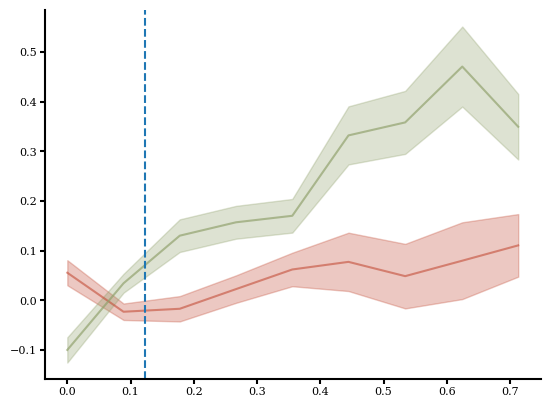

In [93]:
plt.plot(grouped['s_center'], pop1_firing_rates, color='#c34b3596')
plt.fill_between(grouped['s_center'].values.tolist(),pop1_firing_rates - pop1_firing_rate_stdevs,pop1_firing_rates + pop1_firing_rate_stdevs, alpha=0.3, color='#c34b3596')

plt.plot(grouped['s_center'], pop2_firing_rates, color='#8fa06aac')
plt.fill_between(grouped['s_center'].values.tolist(),pop2_firing_rates - pop2_firing_rate_stdevs,pop2_firing_rates + pop2_firing_rate_stdevs, alpha=0.3, color='#8fa06aac')

# plt.xticks([0, 0.07, 0.5], labels=['Low', 'Optimal', 'High'])
# plt.xlim([0, 0.6])
plt.axvline(np.median(s_combined), linestyle='--')
# plt.savefig('pop_rates_data.svg', format='svg')